In [2]:
import pandas as pd
from pathlib import Path
import yaml
import matplotlib.pyplot as plt

In [3]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Color': [['Red', 'Blue'], 'Blue', ['Green', 'Blue']],
    'Value': [10, 20, 30]
})

# Encode the entire DataFrame
encoded_df = pd.get_dummies(df).groupby('Value').sum().astype(int)
print(encoded_df)


       Color_Blue  Color_Green  Color_Red
Value                                    
10              1            0          1
20              1            0          0
30              0            1          0


# Analyzing data from Games endpoint

In [5]:
clean_games_fp = Path(config['games_folder'] + config['games_clean_fp'])

games_df = pd.read_json(clean_games_fp, orient='records')
games_df['updated_at'] = pd.to_datetime(games_df['updated_at'], errors='coerce')
games_df['first_release_date'] = pd.to_datetime(games_df['first_release_date'], errors='coerce')

print(f"Total number of games: {len(games_df)}")
games_df.head()

Total number of games: 19038


,name,rating,updated_at,first_release_date,id
0,Top Drives,90.0,2026-05-01 20:13:39,2017-08-29 00:00:00.000,88508
1,Elemental War 2,-1.0,2026-05-01 20:13:36,2022-05-06 00:00:00.000,159268
2,Jimmie Johnson's Anything with an Engine,65.0,2026-05-01 20:12:39,2011-11-01 00:00:00.000,7023
3,Hills of Steel,-1.0,2026-05-01 20:11:17,1677-09-21 00:12:43.145,146405
4,Blobtown,-1.0,2026-05-01 20:11:09,2024-02-19 00:00:00.000,346759


### How many games of each mode

<BarContainer object of 0 artists>

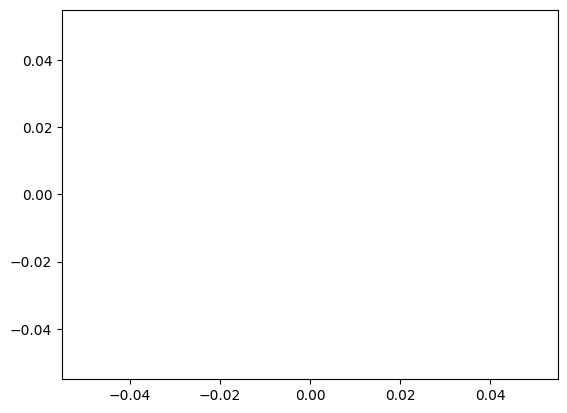

In [6]:
mode_columns = [column for column in games_df.columns if "game_modes" in column]

game_modes_df = games_df[mode_columns]

game_modes_df.columns = [column[len('game_modes_'):] for column in game_modes_df.columns]

game_mode_amounts = game_modes_df.sum().sort_values(ascending = True)

plt.barh(game_mode_amounts.index, game_mode_amounts.values)

### How many games of each genre

<BarContainer object of 0 artists>

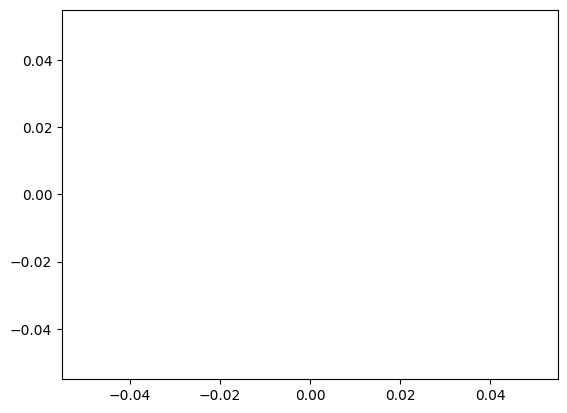

In [7]:
genre_columns = [column for column in games_df.columns if "genres" in column]

genres_df = games_df[genre_columns]

genres_df.columns = [column[len('genres_'):] for column in genres_df.columns]

genres_amounts = genres_df.sum().sort_values(ascending = True)

plt.barh(genres_amounts.index, genres_amounts.values)

### How many games from each platform

<BarContainer object of 0 artists>

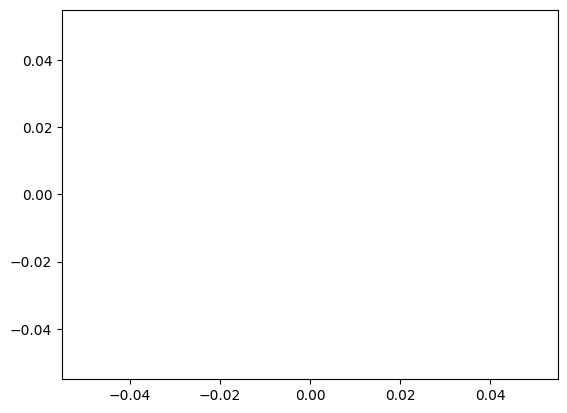

In [8]:
platforms_columns = [column for column in games_df.columns if "platform" in column]

platforms_df = games_df[platforms_columns]

platforms_df.columns = [column[len('platforms_'):] for column in platforms_df.columns]

platforms_amounts = platforms_df.sum().sort_values(ascending = False).head(10).sort_values(ascending=True)

plt.barh(platforms_amounts.index, platforms_amounts.values)

### Distribution of release dates

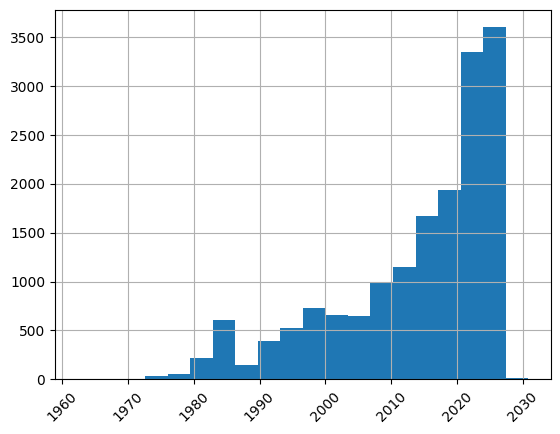

In [9]:
release_dates_without_outliers = games_df[games_df['first_release_date'] > pd.Timestamp('1950')]['first_release_date']

release_dates_without_outliers.hist(bins = 20)
plt.xticks(rotation=45)
plt.show()

# Analyzing data from multiplayer modes endpoint

In [10]:
clean_modes_fp = Path(config['multiplayer_modes_folder'] + config['multiplayer_modes_clean_fp'])

modes_df = pd.read_json(clean_modes_fp, orient='records')

print("Contains " + str(len(modes_df)) + " rows")
modes_df.head()

Contains 53298 rows


,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
0,9953,92273,False,False,False,0,2,False,0,0,Game Boy Color,False
1,9953,92273,False,False,False,0,2,False,0,0,Game Boy Color,False
2,1832,7153,True,True,True,2,0,False,0,0,Xbox 360,False
3,1832,7153,True,True,True,2,0,False,0,0,Xbox 360,False
4,7987,57887,False,False,True,2,2,False,0,0,Xbox One,False


### Distributions of `offlinecoopmax` and `offlinemax`

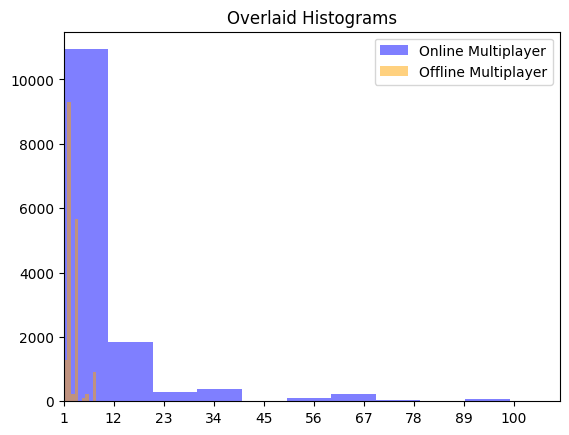

In [11]:
#Online max player data
onlinemax_column = modes_df['onlinemax'].sort_values(ascending = False)

online_threshold = onlinemax_column.quantile(.99)

onlinemax_column = onlinemax_column[(0 < onlinemax_column) & (onlinemax_column < online_threshold)]

#Offline max player data
offlinemax_column = modes_df['offlinemax'].sort_values(ascending = False)

offline_threshold = offlinemax_column.quantile(.99)

offlinemax_column = offlinemax_column[(0 < offlinemax_column) & (offlinemax_column < offline_threshold)]

plot_range = int(max(offline_threshold, online_threshold)+ 10)

plt.hist(onlinemax_column, alpha=0.5, label='Online Multiplayer', color='blue')
plt.hist(offlinemax_column, alpha=0.5, label='Offline Multiplayer', color='orange')
# Formatting
plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(1, plot_range)
plt.xticks(list(range(1,plot_range, int(plot_range / 10))))
plt.show()

Most offline games (expectedly) have very low player counts compared to online games.